# <font color='white'>Análise de Vendas Para Loja de E-commerce com NumPy, Pandas e Matplotlib</font>

## 1. Definição do Problema de Negócio

**1.1. O Problema de Negócio**

Nossa loja de e-commerce está em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado bruto, é como um baú de tesouro trancado: sabemos que há valor ali, mas não conseguimos acessá-lo.

Atualmente, muitas de nossas decisões estratégicas são baseadas em intuição e observações parciais, o que nos leva a enfrentar os seguintes desafios:

- Gestão de Estoque Ineficiente: Não temos clareza sobre quais produtos são nossos "campeões de venda" e quais estão parados nas prateleiras. Isso resulta em excesso de estoque de itens de baixa procura e falta de produtos de alta demanda.

- Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

- Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendências de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

- Expansão sem Direção: Temos o desejo de expandir, mas não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

O problema central é a falta de visibilidade clara sobre a performance do negócio, o que nos impede de tomar decisões rápidas, inteligentes e baseadas em evidências.

**1.2. Objetivos do Projeto**

Este projeto de análise de dados visa transformar nossos dados brutos de vendas em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

- O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
- Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

- Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

- Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir nossos mercados mais fortes.

**1.3. Solução Proposta**

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da nossa plataforma. Utilizando ferramentas de análise de dados (como Python com Pandas, NumPy e Matplotlib), vamos processar essas informações e criar um relatório visual que apresente as descobertas de forma clara e intuitiva para as equipes de gestão, marketing e operações.

**1.4. Resultados Esperados e Benefícios de Negócio**

Ao final deste projeto, esperamos alcançar os seguintes resultados:

- Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, poderemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.

- Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno sobre o investimento (ROI).

- Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

- Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.

## 2. Importação das Bibliotecas

In [4]:
# Instala o pacote watermark pelo Jupyter
!pip install -q -U watermark

In [5]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
import random  
from datetime import datetime, timedelta  

# Comando do Jupyter Notebook que permite exibir gráficos diretamente no notebook
%matplotlib inline  

In [6]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [7]:
#versoes disponível no requirements.txt
%watermark --iversions

matplotlib: 3.9.4
numpy     : 1.26.4
pandas    : 2.3.1
platform  : 1.0.8
seaborn   : 0.13.2



In [9]:
# Para instalar uma versão específica de um pacote, podemos fazer assim (por exemplo):
!pip install -q pandas==2.3.1

In [10]:
%pip show pandas

Name: pandas
Version: 2.3.1
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License
         
         Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
         All rights reserved.
         
         Copyright (c) 2011-2023, Open source contributors.
         
         Redistribution and use in source and binary forms, with or without
         modification, are permitted provided that the following conditions are met:
         
         * Redistributions of source code must retain the above copyright notice, this
           list of conditions and the following disclaimer.
         
         * Redistributions in binary form must reproduce the above copyright notice,
           this list of conditions and the following disclaimer in the documentation
           and/or o

## 3. Função Para Geração de Dados Fictícios

Excelente forma de praticar muito do que vimos até aqui neste capítulo.

In [11]:
#gerar dados fictícios de vendas
def dsa_gera_dados_ficticios(num_registros = 600):
    
    """
    Gera um DataFrame do Pandas com dados de vendas fictícios.
    """

    print(f"\nIniciando a geração de {num_registros} registros de vendas...")

    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00}
    }

    lista_produtos = list(produtos.keys())

    cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }

    lista_cidades = list(cidades_estados.keys())

    dados_vendas = []

    data_inicial = datetime(2026, 1, 1)

    for i in range(num_registros):
        
        produto_nome = random.choice(lista_produtos)

        cidade = random.choice(lista_cidades)

        quantidade = np.random.randint(1, 8)

        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        #desconto de até 10% para alguns produtos específicos
        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0)
        else:
            preco_unitario = produtos[produto_nome]['preco']

        dados_vendas.append({
            'ID_Pedido': 1000 + i,
            'Data_Pedido': data_pedido,
            'Nome_Produto': produto_nome,
            'Categoria': produtos[produto_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100, 150),
            'Cidade': cidade,
            'Estado': cidades_estados[cidade]
        })
    
    print("Geração de dados concluída.\n")

    return pd.DataFrame(dados_vendas)

 ## 4. Gerar, Carregar e Explorar os Dados

In [12]:
df_vendas = dsa_gera_dados_ficticios(500)


Iniciando a geração de 500 registros de vendas...
Geração de dados concluída.



In [13]:
type(df_vendas)

pandas.core.frame.DataFrame

In [14]:
# Shape
# linhas , colunas
df_vendas.shape

(500, 9)

In [15]:
# Exibe as 5 primeiras linhas do DataFrame
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 20:00:00,Laptop Gamer,Eletrônicos,7500.00,7,114,Belo Horizonte,MG
1,1001,2026-01-01 23:00:00,Teclado Mecânico,Acessórios,514.89,7,118,Fortaleza,CE
2,1002,2026-01-01 16:00:00,SSD 1TB,Hardware,600.00,5,116,Porto Alegre,RS
3,1003,2026-01-01 14:00:00,Monitor Ultrawide,Eletrônicos,2800.00,2,118,Rio de Janeiro,RJ
4,1004,2026-01-01 17:00:00,Headset 7.1,Acessórios,800.00,1,119,Porto Alegre,RS


In [16]:
# Exibe as 5 últimas linhas do DataFrame
df_vendas.tail()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
495,1495,2026-04-10 17:00:00,Mouse Vertical,Acessórios,247.96,5,128,Belo Horizonte,MG
496,1496,2026-04-10 22:00:00,Placa de Vídeo,Hardware,4500.00,1,121,Rio de Janeiro,RJ
497,1497,2026-04-10 16:00:00,Placa de Vídeo,Hardware,4500.00,2,149,Belo Horizonte,MG
498,1498,2026-04-10 02:00:00,Headset 7.1,Acessórios,800.00,3,136,Curitiba,PR
499,1499,2026-04-10 12:00:00,Laptop Gamer,Eletrônicos,7500.00,1,108,Porto Alegre,RS


In [17]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 35.3+ KB


In [18]:
# Resumo estatístico
df_vendas.describe()

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,500.000000,500,500.00000,500.000000,500.000000
mean,1249.500000,2026-02-20 00:08:02.400000256,2167.37884,4.072000,123.696000
min,1000.000000,2026-01-01 14:00:00,225.24000,1.000000,100.000000
25%,1124.750000,2026-01-26 09:30:00,534.26750,2.000000,113.000000
50%,1249.500000,2026-02-20 00:00:00,800.00000,4.000000,123.000000
75%,1374.250000,2026-03-16 22:00:00,2800.00000,6.000000,135.000000
max,1499.000000,2026-04-10 22:00:00,7500.00000,7.000000,149.000000
std,144.481833,NaN,2375.25646,2.012689,13.754051


In [19]:
# Tipos de dados
df_vendas.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
dtype: object

## 5. Limpeza, Pré-Processamento e Engenharia de Atributos

In [21]:
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [22]:
# Criando coluna com base nas colunas nativas já criadas
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [23]:
# Criando uma coluna de status de entrega
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rápida' if estado in ['SP', 'RJ', 'MG'] else 'Normal')

In [48]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
 9   Faturamento     500 non-null    float64       
 10  Status_Entrega  500 non-null    object        
 11  Mes             500 non-null    period[M]     
dtypes: datetime64[ns](1), float64(2), int64(3), object(5), period[M](1)
memory usage: 47.0+ KB


In [25]:
# Exibe as 5 primeiras linhas novamente para ver as novas colunas
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 20:00:00,Laptop Gamer,Eletrônicos,7500.00,7,114,Belo Horizonte,MG,52500.00,Rápida
1,1001,2026-01-01 23:00:00,Teclado Mecânico,Acessórios,514.89,7,118,Fortaleza,CE,3604.23,Normal
2,1002,2026-01-01 16:00:00,SSD 1TB,Hardware,600.00,5,116,Porto Alegre,RS,3000.00,Normal
3,1003,2026-01-01 14:00:00,Monitor Ultrawide,Eletrônicos,2800.00,2,118,Rio de Janeiro,RJ,5600.00,Rápida
4,1004,2026-01-01 17:00:00,Headset 7.1,Acessórios,800.00,1,119,Porto Alegre,RS,800.00,Normal


## 6. Análise 1 - Top 10 Produtos Mais Vendidos
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
Quais os top 10 produtos mais vendidos?

In [26]:
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [27]:
top_10_produtos

Nome_Produto
Teclado Mecânico     340
Cadeira Gamer        315
Mouse Vertical       295
Monitor Ultrawide    244
Laptop Gamer         239
Headset 7.1          212
SSD 1TB              205
Placa de Vídeo       186
Name: Quantidade, dtype: int64

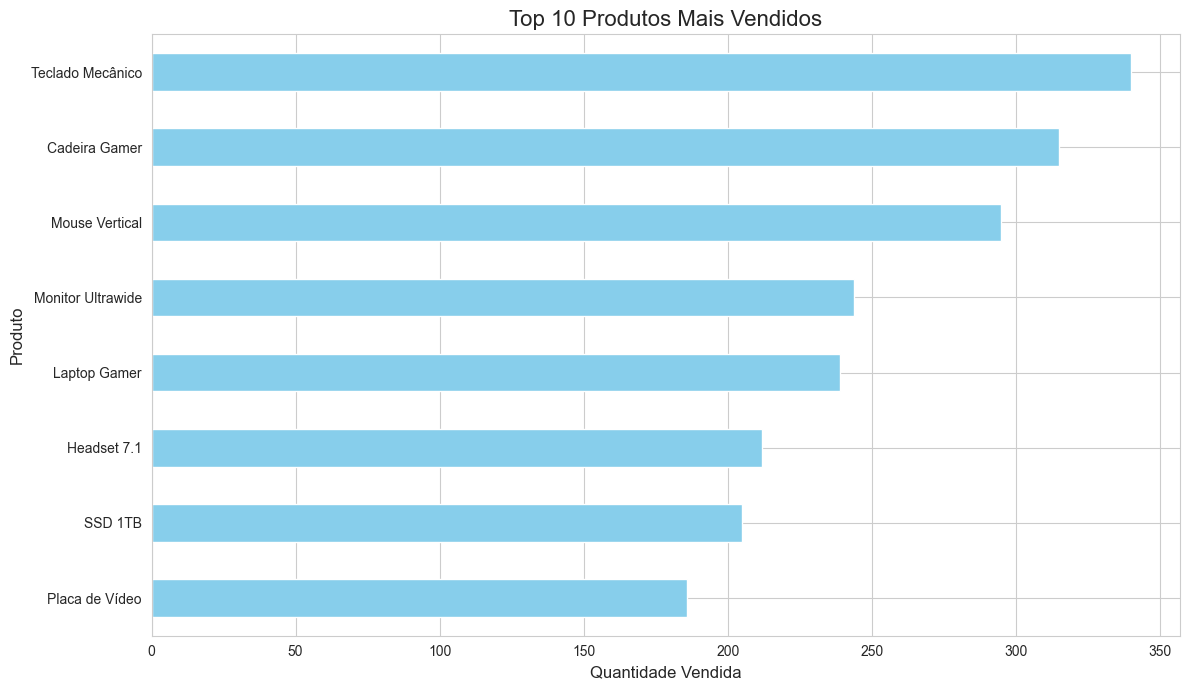

In [28]:
sns.set_style("whitegrid")

plt.figure(figsize = (12, 7))

top_10_produtos.sort_values(ascending = True).plot(kind = 'barh', color = 'skyblue')

plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)

plt.tight_layout()
plt.show()

## 7. Análise 2 - Faturamento Mensal

Qual foi o faturamento mensal?

In [34]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 20:00:00,Laptop Gamer,Eletrônicos,7500.00,7,114,Belo Horizonte,MG,52500.00,Rápida,2026-01
1,1001,2026-01-01 23:00:00,Teclado Mecânico,Acessórios,514.89,7,118,Fortaleza,CE,3604.23,Normal,2026-01
2,1002,2026-01-01 16:00:00,SSD 1TB,Hardware,600.00,5,116,Porto Alegre,RS,3000.00,Normal,2026-01
3,1003,2026-01-01 14:00:00,Monitor Ultrawide,Eletrônicos,2800.00,2,118,Rio de Janeiro,RJ,5600.00,Rápida,2026-01
4,1004,2026-01-01 17:00:00,Headset 7.1,Acessórios,800.00,1,119,Porto Alegre,RS,800.00,Normal,2026-01


In [35]:
df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [36]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 20:00:00,Laptop Gamer,Eletrônicos,7500.00,7,114,Belo Horizonte,MG,52500.00,Rápida,2026-01
1,1001,2026-01-01 23:00:00,Teclado Mecânico,Acessórios,514.89,7,118,Fortaleza,CE,3604.23,Normal,2026-01
2,1002,2026-01-01 16:00:00,SSD 1TB,Hardware,600.00,5,116,Porto Alegre,RS,3000.00,Normal,2026-01
3,1003,2026-01-01 14:00:00,Monitor Ultrawide,Eletrônicos,2800.00,2,118,Rio de Janeiro,RJ,5600.00,Rápida,2026-01
4,1004,2026-01-01 17:00:00,Headset 7.1,Acessórios,800.00,1,119,Porto Alegre,RS,800.00,Normal,2026-01


In [37]:
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

In [38]:
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [39]:
faturamento_mensal.map('R$ {:,.2f}'.format)

Mes
2026-01    R$ 1,203,298.71
2026-02    R$ 1,101,968.65
2026-03    R$ 1,371,822.56
2026-04      R$ 554,016.78
Name: Faturamento, dtype: object

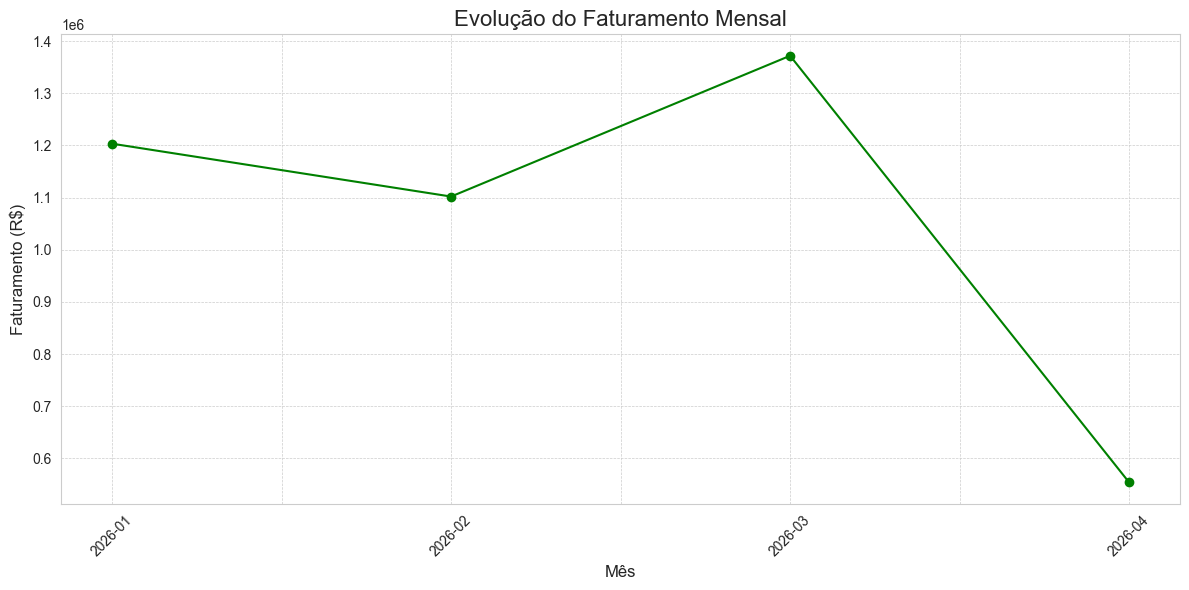

In [40]:
plt.figure(figsize = (12, 6))

faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'green')

plt.title('Evolução do Faturamento Mensal', fontsize = 16)

# Rótulo do eixo X
plt.xlabel('Mês', fontsize = 12)

# Rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

plt.xticks(rotation = 45)

plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

plt.tight_layout()

plt.show()

## 8. Análise 3 - Vendas Por Estado

Qual o total de vendas por estado?

In [41]:
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending = False)

In [42]:
vendas_estado.map('R$ {:,.2f}'.format)

Estado
MG    R$ 828,532.82
BA    R$ 647,142.60
RJ    R$ 646,556.84
PR    R$ 627,808.87
SP    R$ 560,244.70
CE    R$ 504,103.10
RS    R$ 416,717.77
Name: Faturamento, dtype: object

https://seaborn.pydata.org/generated/seaborn.color_palette.html

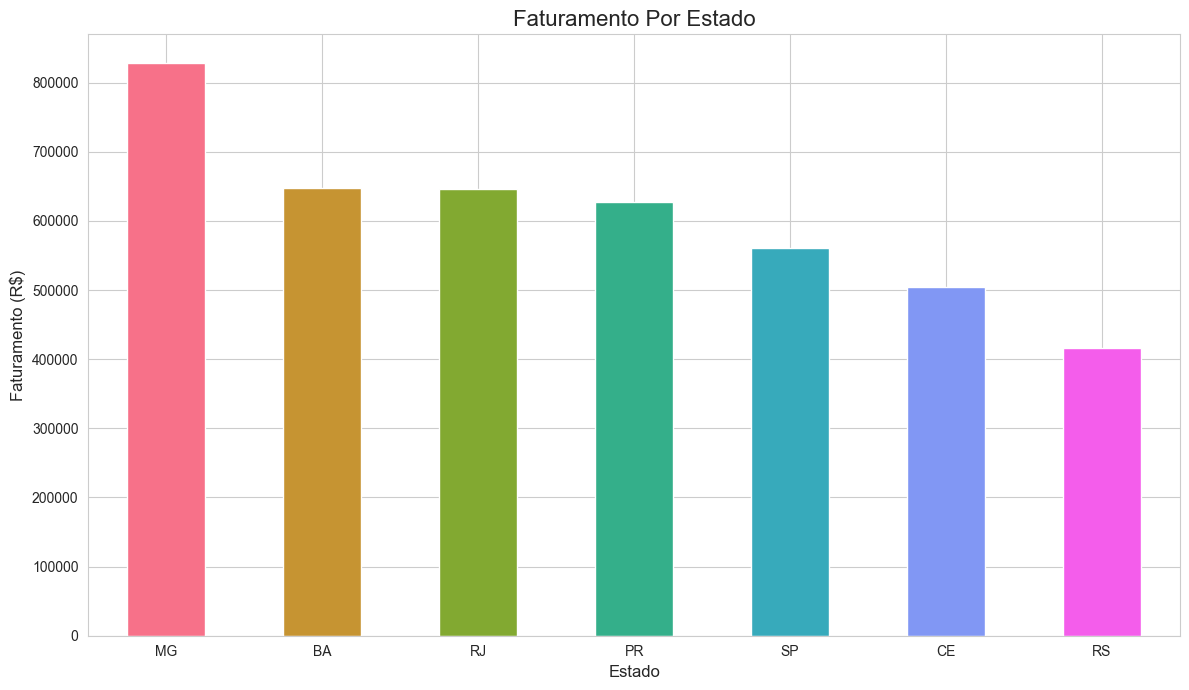

In [43]:
plt.figure(figsize = (12, 7))

vendas_estado.plot(kind = 'bar', color = sns.color_palette("husl", 7))

plt.title('Faturamento Por Estado', fontsize = 16)

plt.xlabel('Estado', fontsize = 12)

plt.ylabel('Faturamento (R$)', fontsize = 12)

plt.xticks(rotation = 0)

plt.tight_layout()

plt.show()

## 9. Análise 4 - Faturamento Por Categoria

Qual o faturamento total por categoria?

In [44]:
faturamento_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)

In [45]:
faturamento_categoria.map('R$ {:,.2f}'.format)

Categoria
Eletrônicos    R$ 2,475,700.00
Hardware         R$ 960,000.00
Acessórios       R$ 417,406.70
Móveis           R$ 378,000.00
Name: Faturamento, dtype: object

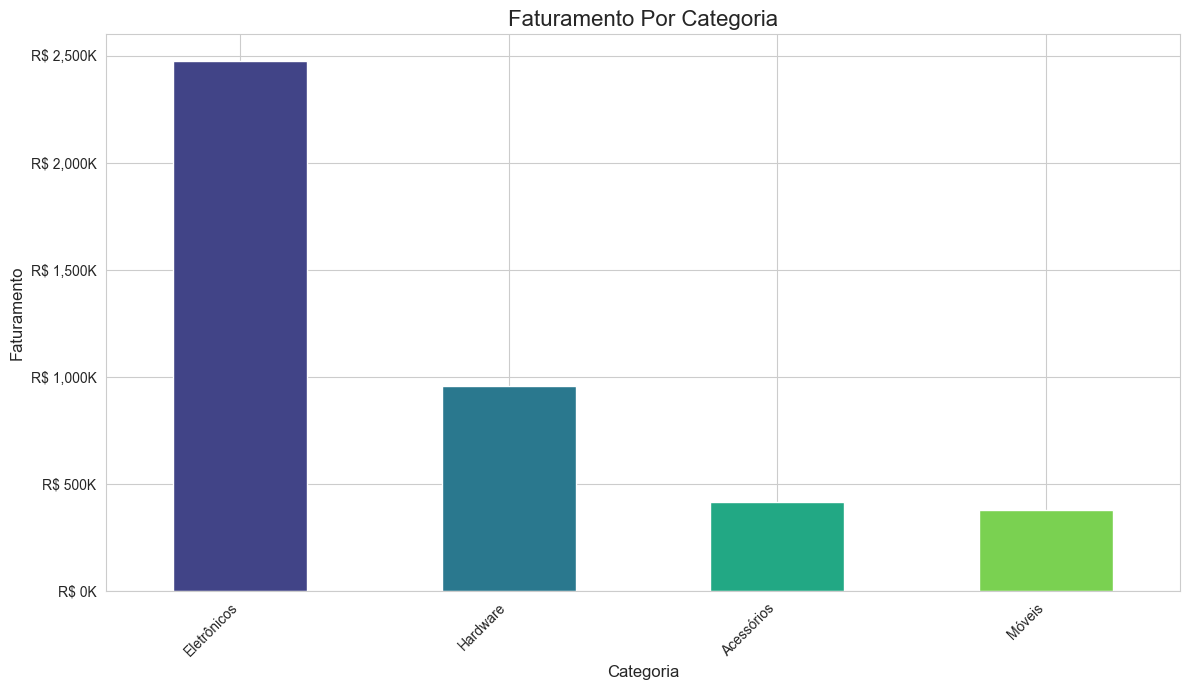

In [47]:
from matplotlib.ticker import FuncFormatter

faturamento_ordenado = faturamento_categoria.sort_values(ascending = False)

fig, ax = plt.subplots(figsize = (12, 7))

def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)

ax.yaxis.set_major_formatter(formatter)

faturamento_ordenado.plot(kind = 'bar', ax = ax, color = sns.color_palette("viridis", len(faturamento_ordenado)))

ax.set_title('Faturamento Por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

plt.xticks(rotation = 45, ha = 'right')

plt.tight_layout()

plt.show()